In [1]:
import sys
import os

import pandas as pd
import json
from datasets import load_dataset, Dataset
from huggingface_hub import login

from dotenv import load_dotenv

# Load Env Variables
load_dotenv()
# load Benchmark Data
# Paste your token here (or load from environment variable)
hf_token = os.getenv("HF_ACCESS_TOKEN")
login(token=hf_token)

/home/anaconda3/envs/myo_thesis/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# models = [
#     "llava_34b",
#     "gemma3_27b",
#     "llava_med_v1.5_mistral_7b",
#     "mistral_small3.2_24b",
#     "qwen2.5vl_72b",
#     "llama3.2_vision_11b_instruct",
#     # "qwen3_vl_32b",
# ]

from models_config import models
models = list(models.keys())

In [4]:
import re

def extract_bounding_box(text):
    """
    Extract bounding box coordinates from an LLM natural language response.
    Expected format inside text: [x,y,w,h] with float numbers.
    Returns list of floats if found, otherwise False.
    """
    match = re.search(r"\[([\d\.\,\s]+)\]", text)
    if match:
        coords = [float(x.strip()) for x in match.group(1).split(",")]
        if len(coords) == 4:
            return coords
    return False


## There are some issues with the Negative Accuracies which are greater than 1. Therefore, I fixied that in the following code.

In [4]:
# from statistics import mean 

# output_csv = "results/conceptbench_result.csv"

# for model_name in models:

#     print(f"Result analysis for {model_name}")

#     dataset_path = f"myothiha/conceptbench_path_vqa_result_{model_name}"
#     dataset = load_dataset(dataset_path, split="train", cache_dir="/mnt/synology/myothiha/HF_CACHE")

#     overall_positive_accuracy = []
#     overall_negative_accuracy = []
#     positive_accuracy_detail = dict()
#     negative_accuracy_detail = dict()
#     new_reasoning_results = []
#     for i, row in enumerate(dataset):

#         conceptual_understanding = json.loads(row['reasoning_result'])

#         for concept, result in conceptual_understanding.items():

#             if result:
#                 result['localization'] = result['localization']
#                 for dimension, reasoning_results in result['positive_reasoning_results'].items():
                    
#                     if dimension not in positive_accuracy_detail.keys():
#                         positive_accuracy_detail[dimension] = []

#                     for reasoning_result in reasoning_results:
#                         # print("Positive Reasoning Result:", reasoning_result['model_answer'])
#                         if "yes" in reasoning_result['model_answer'].lower():
#                             positive_accuracy_detail[dimension].append(1)
#                         else:
#                             positive_accuracy_detail[dimension].append(0)

#                 for dimension, reasoning_results in result['negative_reasoning_results'].items():

#                     if dimension not in negative_accuracy_detail.keys():
#                         negative_accuracy_detail[dimension] = []

#                     for reasoning_result in reasoning_results:
#                         # print("Negative Reasoning Result:", reasoning_result['model_answer'])
#                         if "no" in reasoning_result['model_answer'].lower():
#                             negative_accuracy_detail[dimension].append(1)
#                         else:
#                             negative_accuracy_detail[dimension].append(0)

#                 positive_accuracy_for_each_dimension = {
#                     dim: round(mean(acc_list), 2) 
#                     for dim, acc_list in positive_accuracy_detail.items()
#                     if acc_list
#                 }
#                 negative_accuracy_for_each_dimension = {
#                     dim: round(mean(acc_list), 2)
#                     for dim, acc_list in negative_accuracy_detail.items()
#                     if acc_list
#                 }

#                 # compute average accuracy            
#                 avg_positive_accuracy = mean(positive_accuracy_for_each_dimension.values())
#                 avg_negative_accuracy = mean(negative_accuracy_for_each_dimension.values())
                
#                 # Remove later. just for debugging.
#                 if avg_negative_accuracy > 1:
#                     print("Average Negative Accuracy for concept", concept, ":", round(avg_negative_accuracy, 2))
                
#                 result["positive_accuracy"] = round(avg_positive_accuracy, 2)
#                 result["negative_accuracy"] = round(avg_negative_accuracy, 2)
#                 result["positive_accuracy_details"] = positive_accuracy_for_each_dimension
#                 result["negative_accuracy_details"] = negative_accuracy_for_each_dimension
        
#         # print(json.dumps(conceptual_understanding))
#         # print(row["model_answer"])
#         row['reasoning_result'] = json.dumps(conceptual_understanding)
#         new_reasoning_results.append(row)
#         # break

#     new_dataset_path = dataset_path + "_processed"

#     ds = Dataset.from_list(new_reasoning_results)
#     ds.push_to_hub(
#         new_dataset_path,  # creates the dataset repo if it doesn't exist
#         private=False
#     )
#     # break

In [7]:
cache_dir = os.getenv("HF_CACHE_DIR")

In [19]:
from statistics import mean 

output_csv = "results/conceptbench_result.csv"

for model_name in models:

    print(f"Result analysis for {model_name}")

    dataset_path = f"myothiha/conceptbench_path_vqa_result_2_{model_name}_evaluated"
    dataset = load_dataset(dataset_path, split="train", cache_dir=cache_dir)

    concept_localization = []
    overall_positive_accuracy = []
    overall_negative_accuracy = []
    positive_accuracy_detail = dict()
    negative_accuracy_detail = dict()
    answer_accuracies = []
    # icl_answer_accuracies = []
    for i, row in enumerate(dataset):

        # Accuracy for answer for original task.
        model_answer_accuracy = row['model_answer_accuracy']
        if model_answer_accuracy is None:
            model_answer_accuracy = 0.0
        answer_accuracies.append(model_answer_accuracy)
        
        # icl_answer_accuracies.append(row['knowledge_answer_accuracy'])

        conceptual_understanding = json.loads(row['reasoning_result'])

        for concept, result in conceptual_understanding.items():
            if result:
                try:
                    localization = extract_bounding_box(result['localization'])
                except Exception as e:
                    localization = False
                    print("Error extracting bounding box for concept:", concept, "Error:", e)

                if localization:
                    concept_localization.append(True)
                else:
                    concept_localization.append(False)
                    # continue

                # print("Concept:", concept, "Localization:", localization)
                positive_accuracy = result['positive_accuracy']
                
                # Positive accuracy might become none, 
                # if this concepts, does not have any knowledge across all dimensions.
                if positive_accuracy:
                    overall_positive_accuracy.append(positive_accuracy)

                negative_accuracy = result['negative_accuracy']
                overall_negative_accuracy.append(negative_accuracy)

                for dimension, accuracy in result['positive_accuracy_details'].items():
                    if accuracy > 1:
                        print("Warning: Accuracy greater than 1 found:", accuracy)
                    positive_dimension = f"positive_{dimension}"
                    if positive_dimension not in positive_accuracy_detail.keys():
                        positive_accuracy_detail[positive_dimension] = []
                    positive_accuracy_detail[positive_dimension].append(accuracy)

                for dimension, accuracy in result['negative_accuracy_details'].items():
                    if accuracy > 1:
                        print("Warning: Accuracy greater than 1 found:", accuracy)
                    negative_dimension = f"negative_{dimension}"
                    if negative_dimension not in negative_accuracy_detail.keys():
                        negative_accuracy_detail[negative_dimension] = []
                    negative_accuracy_detail[negative_dimension].append(accuracy)

    average_localization_accuracy = round(mean(concept_localization), 2)
    average_overall_positive_accuracy = round(mean(overall_positive_accuracy), 2)
    average_overall_negative_accuracy = round(mean(overall_negative_accuracy), 2)
    positive_dimensional_accuracies = {dim: round(mean(acc_list), 2) for dim, acc_list in positive_accuracy_detail.items()}
    negative_dimensional_accuracies = {dim: round(mean(acc_list), 2) for dim, acc_list in negative_accuracy_detail.items()}
    
    row_df = {
        "model": model_name,
        "answer_accuracy": round(mean(answer_accuracies), 2),
        # "icl_answer_accuracy": round(mean(icl_answer_accuracies), 2),
        "average_localization_accuracy": average_localization_accuracy,
        "average_overall_positive_accuracy": average_overall_positive_accuracy,
        "average_overall_negative_accuracy": average_overall_negative_accuracy,
        **positive_dimensional_accuracies,
        **negative_dimensional_accuracies
    }

    pd.DataFrame([row_df]).to_csv(output_csv, mode='a', header=not os.path.exists(output_csv), index=False)
    # if model_name == "qwen2.5vl_72b" or True:
    #     print("Average Positive Accuracy", average_overall_positive_accuracy)
    #     print("Average Negative Accuracy", average_overall_negative_accuracy)
        
    #     for dimension, accuracy in positive_dimensional_accuracies.items():
    #         print(f"\tAverage Positive Accuracy for {dimension}: ", round(accuracy, 2))

    #     for dimension, accuracy in negative_dimensional_accuracies.items():
    #         print(f"\tAverage Negative Accuracy for {dimension}: ", round(accuracy, 2))


Result analysis for llava_34b
Result analysis for gemma3_27b
Result analysis for llava_med_v1.5_mistral_7b
Result analysis for mistral_small3.2_24b
Result analysis for qwen2.5vl_72b
Result analysis for llama3.2_vision_11b_instruct
Error extracting bounding box for concept: oral Error: could not convert string to float: '...'
Error extracting bounding box for concept: oral Error: could not convert string to float: '...'
Error extracting bounding box for concept: oral Error: could not convert string to float: '...'
Error extracting bounding box for concept: cystadenocarcinoma Error: could not convert string to float: ''
Error extracting bounding box for concept: principal_mechanisms_of_haemolysis Error: could not convert string to float: ''
Error extracting bounding box for concept: newborn_cord_around_neck Error: could not convert string to float: ''
Error extracting bounding box for concept: heart Error: could not convert string to float: ''
Error extracting bounding box for concept: h

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

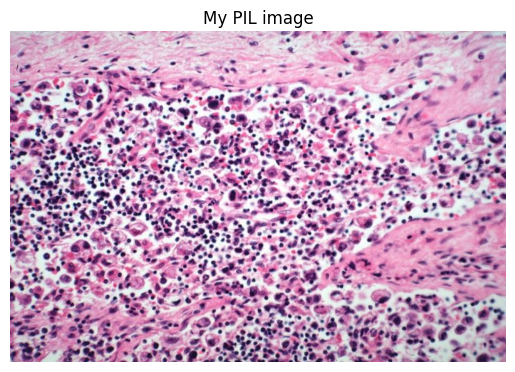

Question: what does this image show?
Ground Truth Answer: anaplastic adenocarcinoma from stomach
Model Answer: This image shows a microscopic view of a tissue sample, likely from a biopsy or surgical specimen, displaying a mixed inflammatory infiltrate with numerous eosinophils and lymphocytes, suggestive of an allergic or parasitic reaction.
Conceptual Understanding: anaplastic_adenocarcinoma
Overall Positive Accuracy: 0.55
  properties: 0.62
  functions: 0.8
  relational: 0.22
Overall Negative Accuracy: 0.52
  properties: 0.5
  functions: 0.6
  relational: 0.7
  contexual_properties: 0.4
  contexual_behavior: 0.4
Conceptual Understanding: stomach
Overall Positive Accuracy: 0.49
  properties: 0.5
  functions: 0.33
  relational: 0.4
  contexual_properties: 0.6
  contexual_behavior: 0.6
Overall Negative Accuracy: 0.36
  properties: 0.4
  functions: 0.6
  relational: 0.4
  contexual_properties: 0.3
  contexual_behavior: 0.1


In [18]:
for i, row in enumerate(dataset):
    plt.imshow(row["image"])
    plt.axis('off')           # optional: hide axes
    plt.title('My PIL image') # optional
    plt.show()

    print(f"Question: {row['question']}")
    print(f"Ground Truth Answer: {row['answer']}")
    print(f"Model Answer: {row['model_answer']}")
    # print(f"Score: {row['score']}")
    conceptual_understanding = json.loads(row['reasoning_result'])

    for concept, result in conceptual_understanding.items():
        print(f"Conceptual Understanding: {concept}")
        
        print("Overall Positive Accuracy:", round(result['positive_accuracy'], 2))
        for dimension, acc in result['positive_accuracy_details'].items():
            print(f"  {dimension}: {round(acc, 2)}")

        print("Overall Negative Accuracy:", round(result['negative_accuracy'], 2))
        for dimension, acc in result['negative_accuracy_details'].items():
            print(f"  {dimension}: {round(acc, 2)}")
    break